# **Lot 2 — Représentations du texte (embeddings)**
### **Projet NLP · Analyse de sentiment des tweets de compagnies aériennes**

On implémente et compare **trois familles de représentation**, toutes alignées sur le **split figé du Lot 1** :

| Famille | Type | Idée |
|---------|------|------|
| **TF-IDF** | fréquentielle, creuse | référence simple et explicable |
| **Word2Vec** | dense, statique | embeddings appris **sur le corpus** (skip-gram, PyTorch) |
| **BERT** (DistilBERT) | dense, **contextuel** | embeddings pré-entraînés (extraction de features) |

> **Objectif clé du projet :** préparer la **matrice de comparaison** *représentations × architectures*.
> Ici on construit les 3 représentations et on en donne un **premier verdict** via une régression
> logistique commune (même classifieur → comparaison équitable des embeddings).


In [1]:
import sys, json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

def find_root():
    for base in [Path.cwd(), *Path.cwd().parents]:
        if (base / "data" / "Tweets.csv").exists():
            return base
    return Path.cwd()

ROOT = find_root()
SRC  = ROOT / "delivarables" / "src"
OUT  = ROOT / "delivarables" / "data_processed"
ART  = ROOT / "delivarables" / "artifacts"; ART.mkdir(exist_ok=True, parents=True)
FIG  = ROOT / "delivarables" / "figures"; FIG.mkdir(exist_ok=True, parents=True)
sys.path.insert(0, str(SRC))
import representations as R
import viz_style as vz
vz.apply_theme()

# Split fige du Lot 1
train = pd.read_csv(OUT/"train.csv"); val = pd.read_csv(OUT/"val.csv"); test = pd.read_csv(OUT/"test.csv")
meta = json.loads((OUT/"meta.json").read_text(encoding="utf-8"))
ytr, yva, yte = train["label"].values, val["label"].values, test["label"].values
for d in (train, val, test):
    d["text_clean"] = d["text_clean"].fillna("")
print("train", train.shape, "| val", val.shape, "| test", test.shape)
print("Metrique principale :", meta["primary_metric"])

train (10248, 9) | val (2196, 9) | test (2196, 9)
Metrique principale : f1_macro


**Protocole d'évaluation des représentations :** on entraîne la **même** régression logistique
(`class_weight='balanced'`) sur chaque représentation et on mesure le **F1-macro sur la validation**.
Le **test reste intouché** (réservé au Lot 4).

In [2]:
def eval_rep(name, Xtr, Xva, store):
    clf = LogisticRegression(max_iter=2000, class_weight="balanced")
    clf.fit(Xtr, ytr)
    f1 = f1_score(yva, clf.predict(Xva), average="macro")
    store[name] = {"dim": Xtr.shape[1], "f1_macro_val": round(f1, 4)}
    print(f"{name:10} dim={Xtr.shape[1]:>5}  F1-macro(val)={f1:.4f}")
    return f1
results = {}

## **1. TF-IDF — référence fréquentielle**

Vectorisation **uni + bigrammes** (`ngram_range=(1,2)`), `min_df=3`, `sublinear_tf=True`, ajustée
**uniquement sur le train** (pas de fuite). On l'applique ensuite à val/test.

In [3]:
t=time.time()
vec = R.build_tfidf(train["text_clean"], ngram_range=(1,2), min_df=3, max_features=20000)
Xtr_tf = vec.transform(train["text_clean"]); Xva_tf = vec.transform(val["text_clean"]); Xte_tf = vec.transform(test["text_clean"])
print(f"Ajuste en {time.time()-t:.1f}s | vocabulaire={len(vec.vocabulary_):,} | densite={Xtr_tf.nnz/(Xtr_tf.shape[0]*Xtr_tf.shape[1])*100:.3f}%")

Ajuste en 1.3s | vocabulaire=12,309 | densite=0.174%


In [4]:
# Termes les plus discriminants par classe (poids LogReg sur TF-IDF)
clf_tf = LogisticRegression(max_iter=2000, class_weight="balanced").fit(Xtr_tf, ytr)
feats = np.array(vec.get_feature_names_out())
for cid, cname in meta["id2label"].items():
    top = np.argsort(clf_tf.coef_[int(cid)])[-10:][::-1]
    print(f"{cname:8}:", ", ".join(feats[top]))

negative: no, not, hours, delayed, why, cancelled, worst, hour, your, nothing
neutral : can you, is there, any, hi, can, or, do you, dm, if, need
positive: great, thanks, love, awesome, thank, amazing, best, thank you, thx, good


**Lecture :** les termes les plus pondérés par classe sont sémantiquement cohérents (ex. *worst, delayed* → négatif ; *thanks, great* → positif), ce qui valide la représentation.

In [5]:
eval_rep("TF-IDF", Xtr_tf, Xva_tf, results)
# sauvegarde pour le Lot 3
import joblib, scipy.sparse as sp
joblib.dump(vec, ART/"tfidf_vectorizer.joblib")
sp.save_npz(ART/"tfidf_train.npz", Xtr_tf); sp.save_npz(ART/"tfidf_val.npz", Xva_tf); sp.save_npz(ART/"tfidf_test.npz", Xte_tf)
print("TF-IDF sauvegarde.")

TF-IDF     dim=12309  F1-macro(val)=0.7570


TF-IDF sauvegarde.


## **2. Word2Vec — embeddings denses appris sur le corpus**

Implémentation **skip-gram + negative sampling en PyTorch** (cf. `src/representations.py`), entraînée
sur les tweets nettoyés. On valide la qualité par les **voisins sémantiques**, puis on construit un
**vecteur de document** = moyenne des vecteurs de mots.

In [6]:
sent_tr = [t.split() for t in train["text_clean"]]
sent_va = [t.split() for t in val["text_clean"]]
sent_te = [t.split() for t in test["text_clean"]]
t=time.time()
emb, w2i, i2w = R.train_word2vec(sent_tr, dim=100, window=5, min_count=3, neg=5, epochs=5, seed=42)
print(f"Entraine en {time.time()-t:.1f}s")

Vocab=3517 | paires=1,323,766 | dim=100 | epochs=5


  epoch 1/5  loss=2.5856


  epoch 2/5  loss=2.4483


  epoch 3/5  loss=2.3863


  epoch 4/5  loss=2.3531


  epoch 5/5  loss=2.3351
Entraine en 38.0s


In [7]:
# Voisins semantiques (validation qualitative)
for w in ["delayed","thanks","bag","hour","gate","cancelled"]:
    nb = R.most_similar(w, emb, w2i, i2w, topn=6)
    if nb: print(f"{w:9} ->", ", ".join(f"{x}({s:.2f})" for x,s in nb))

delayed   -> connecting(0.49), delay(0.44), ctl(0.43), pm(0.43), birmingham(0.43), miss(0.42)
thanks    -> thank(0.53), thx(0.45), speedy(0.45), jh(0.44), detail(0.43), clarification(0.42)
bag       -> checked(0.60), luggage(0.55), golf(0.52), baggage(0.52), lost(0.50), bags(0.47)
hour      -> hours(0.61), half(0.55), minutes(0.55), min(0.54), mins(0.48), hr(0.47)
gate      -> agents(0.55), behavior(0.47), madrid(0.46), agent(0.46), at(0.46), guest(0.46)
cancelled -> flightled(0.76), flighted(0.72), rescheduled(0.52), birmingham(0.50), flightling(0.50), flightlations(0.50)


**Lecture :** les voisins regroupent des mots de même registre (retards, remerciements, bagages…), signe que l'espace vectoriel a capté de la sémantique malgré la petite taille du corpus.

In [8]:
Wtr = R.document_vectors(sent_tr, emb, w2i); Wva = R.document_vectors(sent_va, emb, w2i); Wte = R.document_vectors(sent_te, emb, w2i)
eval_rep("Word2Vec", Wtr, Wva, results)
np.savez(ART/"w2v_embeddings.npz", emb=emb)
json.dump(w2i, open(ART/"w2v_word2idx.json","w"))
np.save(ART/"w2v_doc_train.npy", Wtr); np.save(ART/"w2v_doc_val.npy", Wva); np.save(ART/"w2v_doc_test.npy", Wte)
print("Word2Vec sauvegarde.")

Word2Vec   dim=  100  F1-macro(val)=0.6755
Word2Vec sauvegarde.


## **3. BERT (DistilBERT) — embeddings contextuels**

Extraction de features avec **`distilbert-base-uncased`** : on encode chaque tweet (texte **brut**,
BERT gère sa propre tokenisation) et on fait un **mean pooling masqué** des états cachés → vecteur 768-d.
*(Extraction sur CPU, ~1-2 min.)*

In [9]:
t=time.time()
Btr = R.bert_embeddings(train["text"].fillna(""))
Bva = R.bert_embeddings(val["text"].fillna(""))
Bte = R.bert_embeddings(test["text"].fillna(""))
print(f"Extrait en {time.time()-t:.1f}s | dim={Btr.shape[1]}")
eval_rep("BERT", Btr, Bva, results)
np.save(ART/"bert_train.npy", Btr); np.save(ART/"bert_val.npy", Bva); np.save(ART/"bert_test.npy", Bte)
print("BERT sauvegarde.")

  BERT 10248/10248



Extrait en 291.8s | dim=768


BERT       dim=  768  F1-macro(val)=0.7513
BERT sauvegarde.


## **4. Premier verdict — comparaison des représentations**

Même classifieur (régression logistique pondérée) sur les 3 représentations → on isole l'effet de
**l'embedding seul**. C'est la première ligne de la future **matrice représentations × architectures**.

In [10]:
comp = pd.DataFrame(results).T[["dim","f1_macro_val"]].sort_values("f1_macro_val", ascending=False)
print(comp)
json.dump(results, open(ART/"lot2_representation_scores.json","w"), indent=2)

              dim  f1_macro_val
TF-IDF    12309.0        0.7570
BERT        768.0        0.7513
Word2Vec    100.0        0.6755


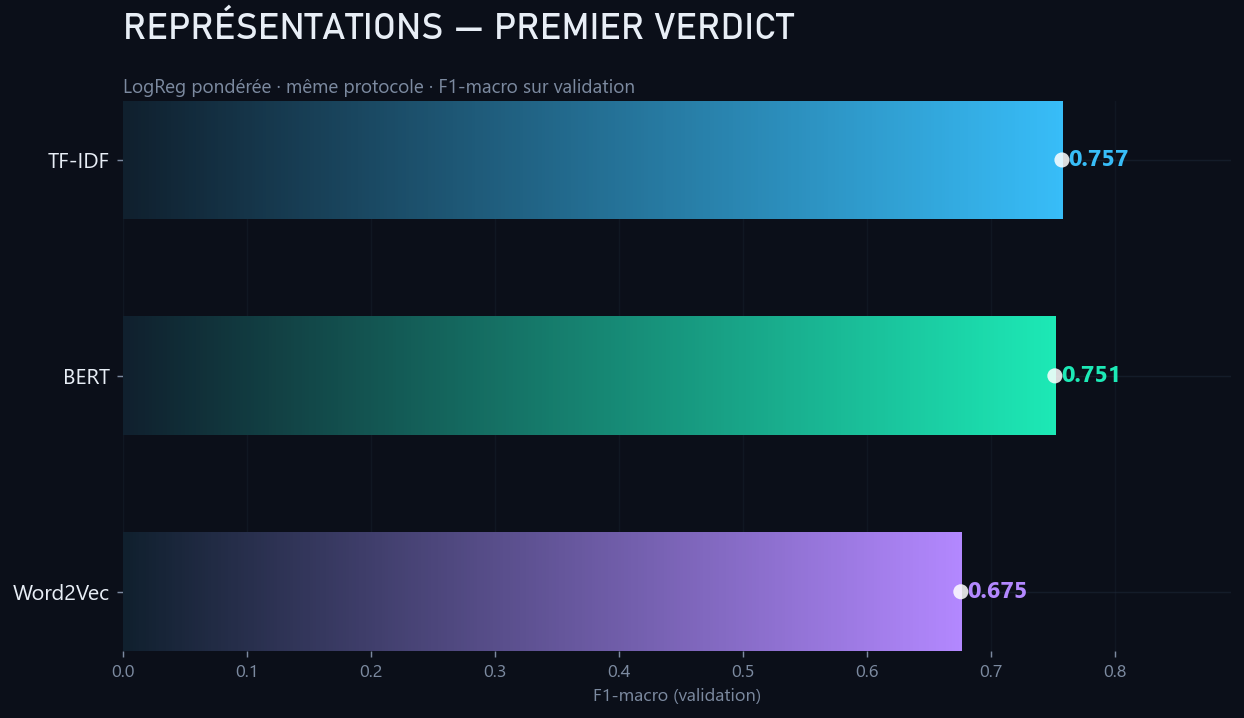

In [11]:
# Visualisation dashboard
order = comp.index.tolist(); vals = comp["f1_macro_val"].values
palette = {"TF-IDF": vz.CYAN, "Word2Vec": vz.PURPLE, "BERT": vz.POS}
fig, ax = plt.subplots(figsize=(11,5.5))
for i,(name,v) in enumerate(zip(order, vals)):
    c = palette.get(name, vz.CYAN)
    vz.gradient_barh(ax, i, v, vz._cmap("#10202E", c, name), height=0.55)
    ax.text(v+0.005, i, f"{v:.3f}", va="center", color=c, fontsize=13, fontweight="bold")
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, color=vz.TEXT, fontsize=12)
ax.set_xlim(0, max(vals)*1.18); ax.set_xlabel("F1-macro (validation)", color=vz.MUTED)
ax.grid(axis="x", alpha=0.3); ax.invert_yaxis()
vz.title(ax, "REPRÉSENTATIONS — PREMIER VERDICT", "LogReg pondérée · même protocole · F1-macro sur validation", size=20)
vz.savefig(fig, FIG/"lot2_comparaison_representations.png"); plt.show()

## **5. Synthèse du Lot 2**

✅ **3 représentations construites** et sauvegardées dans `delivarables/artifacts/` (réutilisées au Lot 3) :
- **TF-IDF** (vectoriseur + matrices creuses), **Word2Vec** (embeddings + vecteurs de document), **BERT** (embeddings 768-d).

✅ **Validation qualitative** : termes discriminants (TF-IDF) et voisins sémantiques (Word2Vec) cohérents.

✅ **Premier verdict quantitatif** (même LogReg) → classe les embeddings sur le F1-macro de validation
(voir tableau + graphe). Cela amorce la **matrice de comparaison** exigée par le sujet.

➡️ **Prochaine étape : Lot 3 — modélisation** (ANN/CNN/LSTM/Attention) en croisant ces représentations
avec les architectures.